In [1]:
import numpy as np
import sys
import os
import time

#CLASS
import classy
import matplotlib.pyplot as plt

In [ ]:
# Fixed parameters
w0 = -0.9
h = 0.7
Omega_ede_values = np.linspace(0.001, 0.09, 15)  


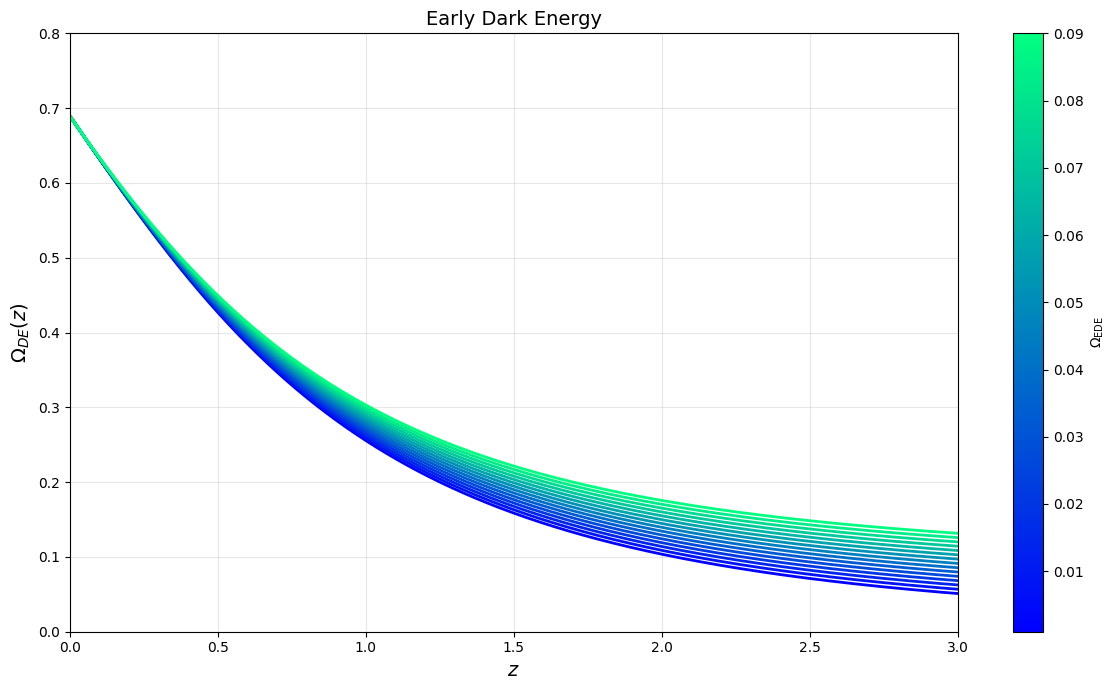

In [11]:
cmap = plt.get_cmap('winter')
colors = [cmap(i / (len(Omega_ede_values) - 1)) for i in range(len(Omega_ede_values))]

fig, ax = plt.subplots(figsize=(12, 7))

for i, Omega_ede in enumerate(Omega_ede_values):
     cosmo = classy.Class()
     cosmo.set({
        'use_ppf': 'yes',
        'tol_initial_Omega_r': 0.1,
        'fluid_equation_of_state': 'EDE',
        'A_s': 2.100549e-09,
        'n_s': 0.9660499,
        'h': h,
        'w0_fld': w0,
        'Omega_EDE': Omega_ede,
        'Omega_Lambda': 0.0,
        'gauge': 'Newtonian',
        'output': 'tCl mPk',
        'P_k_max_1/Mpc': 50.,
        'z_max_pk': 5.0,
        'k_output_values': '0.5',
        'non linear': 'halofit'
    })
     cosmo.compute()
     ba = cosmo.get_background()
     omega_de = ba['(.)rho_fld'] / ba['(.)rho_crit']
   
    
     ax.plot(ba['z'], omega_de, color=colors[i], lw=2)
    


ax.set_xlim(0, 3)
ax.set_ylim(0, 0.8)
ax.set_xlabel('$z$', fontsize=14)
ax.set_ylabel(r'$\Omega_{DE}(z)$', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_title('Early Dark Energy', fontsize=14)


norm = plt.Normalize(vmin=min(Omega_ede_values), vmax=max(Omega_ede_values))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm, ax=ax, label=r'$\Omega_{\mathrm{EDE}}$')  

plt.tight_layout()
plt.show()



In [4]:
l_max_scalars = 2500
l_max_tensors = 600

lcdm_params = {
    'h': 0.67810,
    'omega_b': 0.02238280,
    'omega_cdm': 0.1201075,
    'A_s': 2.100549e-09,
    'tau_reio': 0.05430842,
    'n_s': 0.9660499,  # Needed for accurate spectrum
    'output': 'tCl,pCl,lCl',
    'modes': 's,t',
    'lensing': 'yes',
    'r': 0.1,
    'n_t': 0,
    'l_max_scalars': l_max_scalars,
    'l_max_tensors': l_max_tensors
}

# --- CLASS computation ---
cosmo_lcdm = classy.Class()
cosmo_lcdm.set(lcdm_params)
cosmo_lcdm.compute()

# --- Extract TT spectrum ---
cl_lcdm = cosmo_lcdm.lensed_cl(l_max_scalars)
ell_lcdm = cl_lcdm['ell']
cl_tt_lcdm = 1e10 * ell_lcdm * (ell_lcdm + 1) * cl_lcdm['tt'] / (2 * np.pi)





/var/folders/3q/y_52zqp93p75bklmln9pnttm0000gn/T/ipykernel_2305/1956211746.py:46: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(ell,cl_tt/cl_tt_lcdm-1, color=colors[i], lw=1.5)


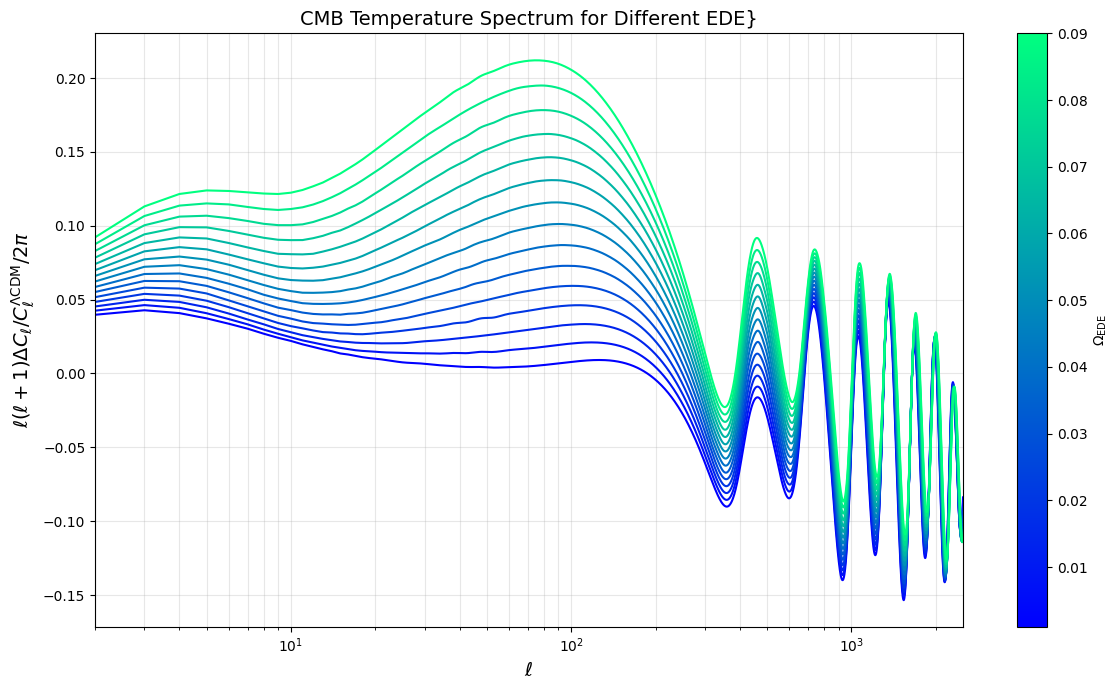

In [18]:
cmap = plt.get_cmap('winter')
colors = [cmap(i / (len(Omega_ede_values) - 1)) for i in range(len(Omega_ede_values))]

fig, ax = plt.subplots(figsize=(12, 7))

ax.set_xlim(2, 2500)
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$\ell (\ell+1) \Delta C_\ell/C_\ell^{\Lambda \text{CDM}} / 2 \pi$", fontsize=14)
ax.set_title("CMB Temperature Spectrum for Different EDE}", fontsize=14)
ax.grid(True, which="both", alpha=0.3)

for i, Omega_ede in enumerate(Omega_ede_values):
    common_settings = {
        'use_ppf': 'yes',
        'tol_initial_Omega_r': 0.1,
        'fluid_equation_of_state': 'EDE',
        'A_s': 2.100549e-09,
        'n_s': 0.9660499,
        'h': h,
        'w0_fld': w0,
        'Omega_EDE': Omega_ede,
        'Omega_Lambda': 0.0,
        'gauge': 'Newtonian',
        'non linear': 'halofit'
    }

    M = classy.Class()

    M.set({
        **common_settings,
        'output': 'tCl,pCl,lCl',
        'modes': 's,t',
        'lensing': 'yes',
        'r': 0.1,
        'n_t': 0,
        'l_max_scalars': l_max_scalars,
        'l_max_tensors': l_max_tensors
    })
    M.compute()

    cl_lensed = M.lensed_cl(l_max_scalars)
    ell = cl_lensed['ell']
    factor = 1e10 * ell * (ell + 1) / (2 * np.pi)
    cl_tt = factor * cl_lensed['tt']

    ax.semilogx(ell,cl_tt/cl_tt_lcdm-1, color=colors[i], lw=1.5)

    M.struct_cleanup()
    M.empty()

# Add colorbar
norm = plt.Normalize(vmin=min(Omega_ede_values), vmax=max(Omega_ede_values))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  #
cbar = fig.colorbar(sm, ax=ax, label=r'$\Omega_{\mathrm{EDE}}$')

plt.tight_layout()
plt.show()


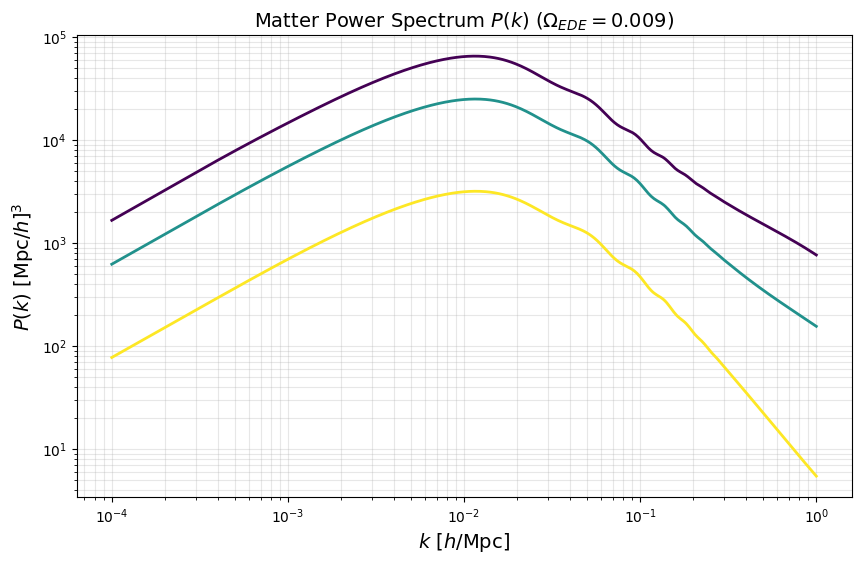

In [78]:

k = np.logspace(-4, 0, 500)
redshifts = [0, 1, 5]
colors = plt.cm.viridis(np.linspace(0, 1, len(redshifts)))

# Plot setup
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.yscale('log')

# Calculate and plot P(k) for each redshift
for z, color in zip(redshifts, colors):
    Pk = np.array([cosmo.pk(ki, z) for ki in k])
    plt.plot(k, Pk, 
             color=color,
             lw=2,
             label=f'z = {z}')

# Formatting
plt.xlabel(r'$k \,\, [h/\mathrm{Mpc}]$', fontsize=14)
plt.ylabel(r'$P(k) \,\, [\mathrm{Mpc}/h]^3$', fontsize=14)
plt.title(r'Matter Power Spectrum $P(k)$ ($\Omega_{EDE}=%.3f$)' % Omega_ede, 
          fontsize=14)
plt.grid(True, which="both", alpha=0.3)



In [6]:
cosmo.sigma8()

0.879184853027757

In [7]:
z = np.linspace(0.0, 5.0, 50)
krange2 = np.logspace(np.log10(1e-4), np.log10(1e-3), num=40, endpoint=False)
krange3 = np.logspace(np.log10(1e-3), np.log10(1e-2), num=60, endpoint=False)
krange4 = np.logspace(np.log10(1e-2), np.log10(1e-1), num=80, endpoint=False)
krange5 = np.logspace(np.log10(1e-1), np.log10(1), num=100, endpoint=False)
krange6 = np.logspace(np.log10(1), np.log10(10), num=120, endpoint=False)

k = np.concatenate((krange2, krange3, krange4, krange5, krange6))
#Linear DS
P_lin = np.array([[cosmo.pk(ki, zi)*h**3.0 for ki in k*h] for zi in z])

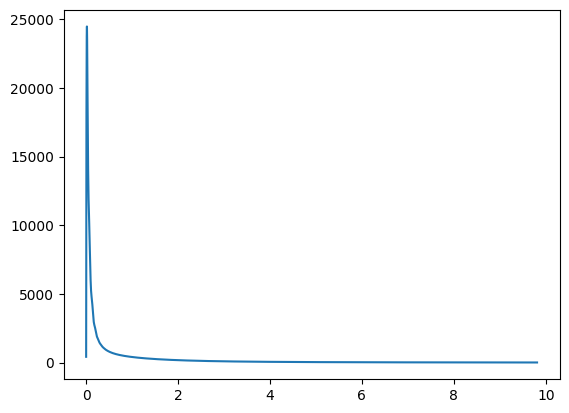

In [10]:
plt.plot(k,P_lin[1])